# PRMP Meta-Analysis: Pooled Effects, Embedding Regime Theory & Publication Figures

**Definitive meta-analysis** across 12 experiments from 5 datasets (Amazon, F1, Stack, HM, Avito).

This notebook demonstrates:
1. **DerSimonian-Laird random-effects meta-analysis** — pooled Cohen's d across 8 independent tasks
2. **Task-type moderator analysis** — regression vs classification subgroups
3. **Embedding-space regime theory** — Spearman correlation between embedding R² and PRMP effect
4. **Publication-quality figures** — forest plot, regime scatter, R² trajectories, ablation bars, subgroup forest, funnel plot, loss-swap, and summary table

Pre-computed per-task effect sizes are loaded from `mini_demo_data.json`; the statistical analysis and all figures are generated live.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally to match Colab env
# Note: scipy==1.16.3 requires Python>=3.11 (Colab). For Python 3.10 fallback use 1.15.3.
if 'google.colab' not in sys.modules:
    import platform
    _py_minor = int(platform.python_version_tuple()[1])
    _scipy_ver = '1.16.3' if _py_minor >= 11 else '1.15.3'
    _pip(f'numpy==2.0.2', f'scipy=={_scipy_ver}', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires scikit-learn>=1.7.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
from collections import defaultdict

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats
from loguru import logger

# Configure logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

print("All imports successful!")

All imports successful!


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/evaluation_iter7_definitive_prmp/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"Independent tasks: {len(data['independent_tasks'])}")
print(f"Sensitivity tasks: {len(data['sensitivity_tasks'])}")
print(f"Embedding links: {len(data['embedding_links'])}")
print(f"Lossswap configs: {len(data['lossswap_configs'])}")
print(f"Ablation variants: {len(data['ablation_variants'])}")

Loaded data with keys: ['description', 'independent_tasks', 'sensitivity_tasks', 'embedding_links', 'lossswap_configs', 'lossswap_analysis', 'ablation_variants', 'ablation_fig_data', 'embedding_trajectories', 'stack_embedding_summary', 'regime_theory', 'dataset_colors']
Independent tasks: 8
Sensitivity tasks: 4
Embedding links: 26
Lossswap configs: 4
Ablation variants: 12


## Configuration

All tunable parameters for the analysis. These are set to use the full dataset since the meta-analysis operates on pre-computed effect sizes (fast computation).

In [5]:
# ── Config ──
# No tunable iteration/epoch params needed — this is a meta-analysis over
# pre-computed per-task effect sizes. All 8 tasks are used.
CONFIDENCE_LEVEL = 1.96  # 95% CI z-value
FIGURE_DPI = 150
FIGURE_FONT_SIZE = 10

## Helper Functions: Cohen's d & DerSimonian-Laird Meta-Analysis

In [6]:
def cohens_d(group1, group2):
    """Compute Cohen's d = (mean2 - mean1) / pooled_sd.
    Returns (d, se_d, ci_lo, ci_hi). Positive d means group2 > group1.
    """
    n1, n2 = len(group1), len(group2)
    m1, m2 = np.mean(group1), np.mean(group2)
    s1, s2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)) if (n1 + n2 - 2) > 0 else 1e-10
    if sp < 1e-12:
        sp = 1e-12
    d = (m2 - m1) / sp
    se = np.sqrt((n1 + n2) / (n1 * n2) + d**2 / (2 * (n1 + n2)))
    ci_lo = d - CONFIDENCE_LEVEL * se
    ci_hi = d + CONFIDENCE_LEVEL * se
    return float(d), float(se), float(ci_lo), float(ci_hi)


def variance_of_d(d, n1, n2):
    """Variance of Cohen's d."""
    return (n1 + n2) / (n1 * n2) + d**2 / (2 * (n1 + n2))


def dersimonian_laird(effects, variances):
    """DerSimonian-Laird random-effects meta-analysis.
    Returns dict with pooled_d, se, ci_lo, ci_hi, z, p, Q, I2, tau2, pred_lo, pred_hi.
    """
    k = len(effects)
    effects = np.array(effects)
    variances = np.array(variances)

    w_fe = 1.0 / variances
    d_fe = np.sum(w_fe * effects) / np.sum(w_fe)
    Q = np.sum(w_fe * (effects - d_fe)**2)
    df = k - 1
    p_Q = 1.0 - stats.chi2.cdf(Q, df) if df > 0 else 1.0

    C = np.sum(w_fe) - np.sum(w_fe**2) / np.sum(w_fe)
    tau2 = max(0.0, (Q - df) / C) if C > 0 else 0.0

    w_re = 1.0 / (variances + tau2)
    d_re = np.sum(w_re * effects) / np.sum(w_re)
    se_re = np.sqrt(1.0 / np.sum(w_re))

    ci_lo = d_re - CONFIDENCE_LEVEL * se_re
    ci_hi = d_re + CONFIDENCE_LEVEL * se_re

    z = d_re / se_re if se_re > 0 else 0.0
    p_z = 2.0 * (1.0 - stats.norm.cdf(abs(z)))

    I2 = max(0.0, (Q - df) / Q * 100) if Q > 0 else 0.0

    t_crit = stats.t.ppf(0.975, max(df, 1))
    pred_lo = d_re - t_crit * np.sqrt(tau2 + se_re**2)
    pred_hi = d_re + t_crit * np.sqrt(tau2 + se_re**2)

    return {
        "pooled_d": float(d_re), "se": float(se_re),
        "ci_lo": float(ci_lo), "ci_hi": float(ci_hi),
        "z": float(z), "p_value": float(p_z),
        "Q": float(Q), "Q_p": float(p_Q),
        "I2": float(I2), "tau2": float(tau2),
        "pred_lo": float(pred_lo), "pred_hi": float(pred_hi),
        "k": k,
    }


def eggers_test(effects, se_list):
    """Egger's regression test for funnel plot asymmetry."""
    precision = [1.0 / se for se in se_list]
    std_effects = [e / se for e, se in zip(effects, se_list)]
    if len(effects) < 3:
        return {"intercept": float("nan"), "p_value": float("nan"), "interpretable": False}
    slope, intercept, r, p, stderr = stats.linregress(precision, std_effects)
    return {"intercept": float(intercept), "slope": float(slope),
            "p_value": float(p), "interpretable": len(effects) >= 5}

print("Helper functions defined.")

Helper functions defined.


## DerSimonian-Laird Random-Effects Meta-Analysis

In [7]:
logger.info("Running meta-analysis on pre-computed per-task effect sizes...")

independent_tasks = data["independent_tasks"]
all_tasks = independent_tasks + data["sensitivity_tasks"]

effects = [t["d"] for t in independent_tasks]
variances = [t["se"]**2 for t in independent_tasks]
se_list = [t["se"] for t in independent_tasks]

meta_result = dersimonian_laird(effects, variances)
logger.info(f"Pooled d = {meta_result['pooled_d']:.4f} [{meta_result['ci_lo']:.4f}, {meta_result['ci_hi']:.4f}]")
logger.info(f"Z = {meta_result['z']:.3f}, p = {meta_result['p_value']:.4f}")
logger.info(f"I² = {meta_result['I2']:.1f}%, τ² = {meta_result['tau2']:.4f}")
logger.info(f"Prediction interval: [{meta_result['pred_lo']:.3f}, {meta_result['pred_hi']:.3f}]")

22:14:51|INFO   |Running meta-analysis on pre-computed per-task effect sizes...


22:14:51|INFO   |Pooled d = 0.2367 [-0.3651, 0.8384]


22:14:51|INFO   |Z = 0.771, p = 0.4408


22:14:51|INFO   |I² = 21.5%, τ² = 0.1611


22:14:51|INFO   |Prediction interval: [-0.958, 1.432]


## Task-Type Moderator Analysis

In [8]:
logger.info("Running task-type moderator analysis...")

reg_tasks = [t for t in independent_tasks if t["task_type"] == "regression"]
cls_tasks = [t for t in independent_tasks if t["task_type"] == "classification"]

reg_effects = [t["d"] for t in reg_tasks]
reg_vars = [t["se"]**2 for t in reg_tasks]
cls_effects = [t["d"] for t in cls_tasks]
cls_vars = [t["se"]**2 for t in cls_tasks]

meta_reg = dersimonian_laird(reg_effects, reg_vars) if len(reg_effects) >= 2 else None
meta_cls = dersimonian_laird(cls_effects, cls_vars) if len(cls_effects) >= 2 else None

# Simple meta-regression: does task_type predict d?
if len(reg_effects) >= 2 and len(cls_effects) >= 2:
    x_mod = [0]*len(reg_effects) + [1]*len(cls_effects)
    y_mod = reg_effects + cls_effects
    mod_slope, mod_intercept, mod_r, mod_p, mod_se = stats.linregress(x_mod, y_mod)
    moderator_test = {
        "slope": float(mod_slope), "intercept": float(mod_intercept),
        "p_value": float(mod_p),
        "regression_pooled_d": meta_reg["pooled_d"] if meta_reg else None,
        "classification_pooled_d": meta_cls["pooled_d"] if meta_cls else None,
    }
else:
    moderator_test = {"slope": None, "intercept": None, "p_value": None}

if meta_reg:
    logger.info(f"Regression tasks (k={len(reg_tasks)}): pooled d = {meta_reg['pooled_d']:.4f}")
if meta_cls:
    logger.info(f"Classification tasks (k={len(cls_tasks)}): pooled d = {meta_cls['pooled_d']:.4f}")

22:14:51|INFO   |Running task-type moderator analysis...


22:14:51|INFO   |Regression tasks (k=5): pooled d = 0.3340


22:14:51|INFO   |Classification tasks (k=3): pooled d = 0.0881


## Embedding-Space Regime Theory

In [9]:
logger.info("Computing embedding-space regime theory metrics...")

embedding_links = data["embedding_links"]

# Compute per-dataset mean embedding R²
dataset_emb_r2 = defaultdict(list)
for link in embedding_links:
    if link.get("embedding_r2_standard") is not None:
        dataset_emb_r2[link["dataset"]].append(link["embedding_r2_standard"])

dataset_mean_emb_r2 = {ds: np.mean(vals) for ds, vals in dataset_emb_r2.items()}

# Spearman correlation: embedding R² vs PRMP improvement at task level
task_emb_r2 = []
task_d_values = []
for t in independent_tasks:
    ds = t["dataset"]
    if ds in dataset_mean_emb_r2:
        task_emb_r2.append(dataset_mean_emb_r2[ds])
        task_d_values.append(t["d"])

if len(task_emb_r2) >= 3:
    spearman_rho, spearman_p = stats.spearmanr(task_emb_r2, task_d_values)
else:
    spearman_rho, spearman_p = float("nan"), float("nan")

logger.info(f"FK links analyzed: {len(embedding_links)}")
logger.info(f"Regime: Spearman ρ = {spearman_rho:.3f}, p = {spearman_p:.3f}")
logger.info(f"Dataset mean embedding R²: {dict(dataset_mean_emb_r2)}")

22:14:51|INFO   |Computing embedding-space regime theory metrics...


22:14:51|INFO   |FK links analyzed: 26


22:14:51|INFO   |Regime: Spearman ρ = 0.949, p = 0.051


22:14:51|INFO   |Dataset mean embedding R²: {'Amazon': np.float64(0.5076499999999999), 'Avito': np.float64(0.4452545454545454), 'Stack': np.float64(0.017372727272727272)}


## Egger's Test for Publication Bias

In [10]:
egger = eggers_test(effects, se_list)
logger.info(f"Egger's test: intercept = {egger['intercept']:.3f}, p = {egger['p_value']:.3f}")

22:14:51|INFO   |Egger's test: intercept = -1.411, p = 0.550


## Hypothesis Verdicts

In [11]:
# Compute hypothesis verdicts
h1_systematic = meta_result["p_value"] < 0.05 and meta_result["pooled_d"] > 0
h2_regime = abs(spearman_rho) > 0.3 and spearman_p < 0.1
h3_regression = (meta_reg and meta_cls and meta_reg["pooled_d"] > meta_cls["pooled_d"])

# H4: Check ablation data
ablation_fig_data = data.get("ablation_fig_data", {})
prmp_rmse = ablation_fig_data.get("PRMP", {}).get("rmse_mean", float("inf"))
random_rmse = ablation_fig_data.get("Random Pred", {}).get("rmse_mean", 0)
h4_learned = random_rmse > prmp_rmse

verdicts = {
    "H1_systematic_advantage": {
        "supported": h1_systematic,
        "interpretation": f"Pooled d={meta_result['pooled_d']:.3f} (p={meta_result['p_value']:.4f}), {'significant' if h1_systematic else 'not significant'}",
    },
    "H2_regime_theory": {
        "supported": h2_regime,
        "interpretation": f"ρ={spearman_rho:.3f} (p={spearman_p:.3f}), {'supported' if h2_regime else 'not supported'}",
    },
    "H3_regression_advantage": {
        "supported": bool(h3_regression),
        "interpretation": f"Reg d={meta_reg['pooled_d']:.3f} vs Cls d={meta_cls['pooled_d']:.3f}" if meta_reg and meta_cls else "Insufficient data",
    },
    "H4_learned_predictions_necessary": {
        "supported": h4_learned,
        "interpretation": f"PRMP RMSE={prmp_rmse:.4f} vs Random RMSE={random_rmse:.4f}",
    },
}

for k, v in verdicts.items():
    status = "SUPPORTED" if v["supported"] else "NOT SUPPORTED"
    logger.info(f"  {k}: {status} — {v['interpretation']}")

22:14:51|INFO   |  H1_systematic_advantage: NOT SUPPORTED — Pooled d=0.237 (p=0.4408), not significant


22:14:51|INFO   |  H2_regime_theory: SUPPORTED — ρ=0.949 (p=0.051), supported


22:14:51|INFO   |  H3_regression_advantage: SUPPORTED — Reg d=0.334 vs Cls d=0.088


22:14:51|INFO   |  H4_learned_predictions_necessary: SUPPORTED — PRMP RMSE=0.5343 vs Random RMSE=0.5601


## Cross-Dataset Summary

In [12]:
dataset_summary = {}
for ds in ["Amazon", "F1", "Stack", "HM", "Avito"]:
    ds_tasks = [t for t in independent_tasks if t["dataset"] == ds]
    ds_reg = [t for t in ds_tasks if t["task_type"] == "regression"]
    ds_cls = [t for t in ds_tasks if t["task_type"] == "classification"]
    ds_d_values = [t["d"] for t in ds_tasks]
    dataset_summary[ds] = {
        "n_tasks": len(ds_tasks),
        "n_regression": len(ds_reg),
        "n_classification": len(ds_cls),
        "best_d": float(max(ds_d_values)) if ds_d_values else None,
        "mean_d": float(np.mean(ds_d_values)) if ds_d_values else None,
        "task_names": [t["task"] for t in ds_tasks],
        "mean_embedding_r2": float(dataset_mean_emb_r2.get(ds, float("nan"))),
        "n_fk_links": len([l for l in embedding_links if l["dataset"] == ds]),
    }

for ds, s in dataset_summary.items():
    logger.info(f"  {ds}: {s['n_tasks']} tasks, mean d={s['mean_d']:.3f}" if s['mean_d'] else f"  {ds}: no tasks")

22:14:51|INFO   |  Amazon: 1 tasks, mean d=1.009


22:14:51|INFO   |  F1: 2 tasks, mean d=0.227


22:14:51|INFO   |  Stack: 2 tasks, mean d=-0.685


22:14:51|INFO   |  HM: 2 tasks, mean d=0.509


22:14:51|INFO   |  Avito: 1 tasks, mean d=0.468


## Publication Figures

Generating 8 publication-quality figures from the meta-analysis results.

In [13]:
# Shared style
plt.rcParams.update({
    "font.size": FIGURE_FONT_SIZE,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": FIGURE_DPI,
})

dataset_colors = data["dataset_colors"]
print("Figure style configured.")

Figure style configured.


### Figure 1: Forest Plot

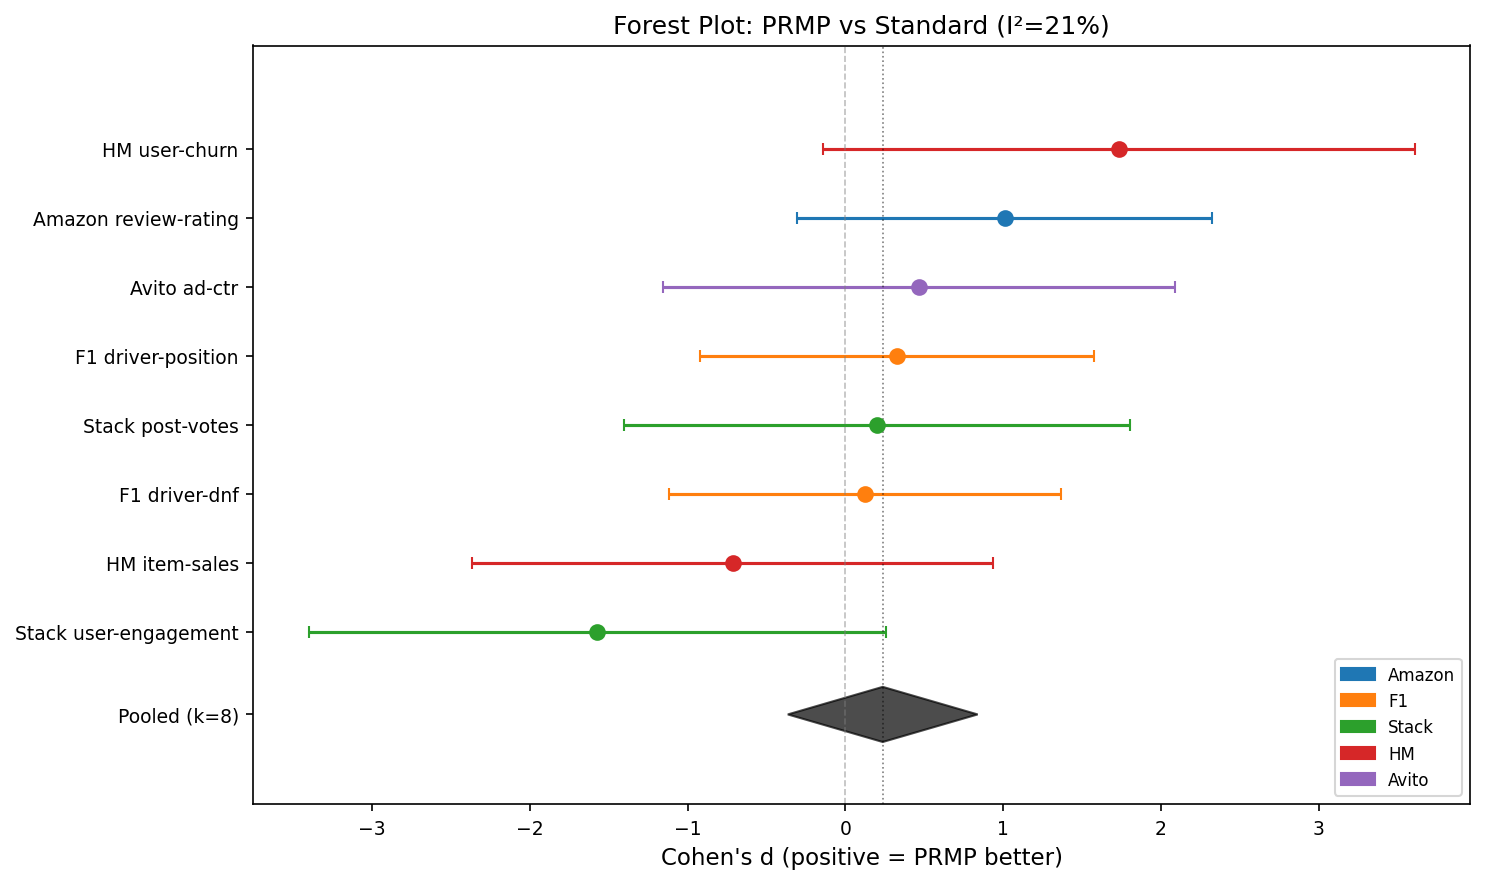

In [14]:
fig1, ax1 = plt.subplots(figsize=(10, 6))
sorted_tasks = sorted(independent_tasks, key=lambda t: t["d"])
y_positions = list(range(len(sorted_tasks)))

for i, t in enumerate(sorted_tasks):
    color = dataset_colors.get(t["dataset"], "gray")
    ax1.errorbar(t["d"], i, xerr=[[t["d"] - t["ci_lo"]], [t["ci_hi"] - t["d"]]],
                 fmt="o", color=color, markersize=7, capsize=3, linewidth=1.5)

# Pooled estimate diamond
diamond_y = -1.2
diamond = plt.Polygon([
    [meta_result["ci_lo"], diamond_y],
    [meta_result["pooled_d"], diamond_y + 0.4],
    [meta_result["ci_hi"], diamond_y],
    [meta_result["pooled_d"], diamond_y - 0.4],
], closed=True, facecolor="black", edgecolor="black", alpha=0.7)
ax1.add_patch(diamond)

ax1.axvline(x=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.axvline(x=meta_result["pooled_d"], color="black", linestyle=":", linewidth=0.8, alpha=0.5)

ax1.set_yticks(y_positions + [-1.2])
ax1.set_yticklabels([t["task"] for t in sorted_tasks] + [f"Pooled (k={meta_result['k']})"])
ax1.set_xlabel("Cohen's d (positive = PRMP better)")
ax1.set_title(f"Forest Plot: PRMP vs Standard (I²={meta_result['I2']:.0f}%)")

handles = [mpatches.Patch(color=c, label=ds) for ds, c in dataset_colors.items()
           if any(t["dataset"] == ds for t in independent_tasks)]
ax1.legend(handles=handles, loc="lower right", fontsize=8)
ax1.set_ylim(-2.5, len(sorted_tasks) + 0.5)
fig1.tight_layout()
plt.show()

### Figure 2: Embedding Regime Scatter

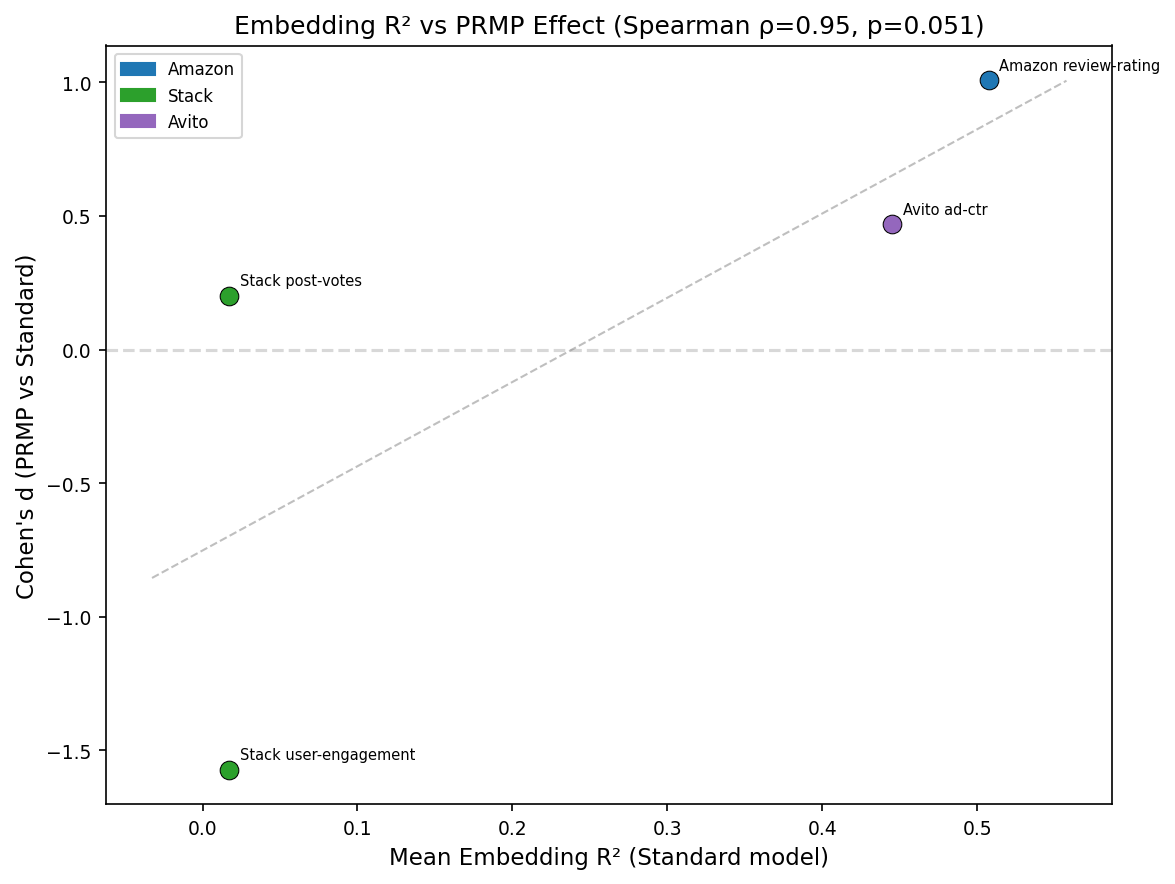

In [15]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

for t in independent_tasks:
    ds = t["dataset"]
    emb_r2 = dataset_mean_emb_r2.get(ds)
    if emb_r2 is not None and not np.isnan(emb_r2):
        color = dataset_colors.get(ds, "gray")
        ax2.scatter(emb_r2, t["d"], color=color, s=80, zorder=5, edgecolors="black", linewidth=0.5)
        ax2.annotate(t["task"], (emb_r2, t["d"]), fontsize=7, xytext=(5, 5),
                    textcoords="offset points")

if len(task_emb_r2) >= 3 and not np.isnan(spearman_rho):
    z = np.polyfit(task_emb_r2, task_d_values, 1)
    p = np.poly1d(z)
    x_range = np.linspace(min(task_emb_r2) - 0.05, max(task_emb_r2) + 0.05, 50)
    ax2.plot(x_range, p(x_range), "--", color="gray", alpha=0.5, linewidth=1)
    ax2.set_title(f"Embedding R² vs PRMP Effect (Spearman ρ={spearman_rho:.2f}, p={spearman_p:.3f})")
else:
    ax2.set_title("Embedding R² vs PRMP Effect")

ax2.set_xlabel("Mean Embedding R² (Standard model)")
ax2.set_ylabel("Cohen's d (PRMP vs Standard)")
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
handles = [mpatches.Patch(color=c, label=ds) for ds, c in dataset_colors.items()
           if ds in dataset_mean_emb_r2]
ax2.legend(handles=handles, loc="best", fontsize=8)
fig2.tight_layout()
plt.show()

### Figure 3: R² Trajectory Comparison

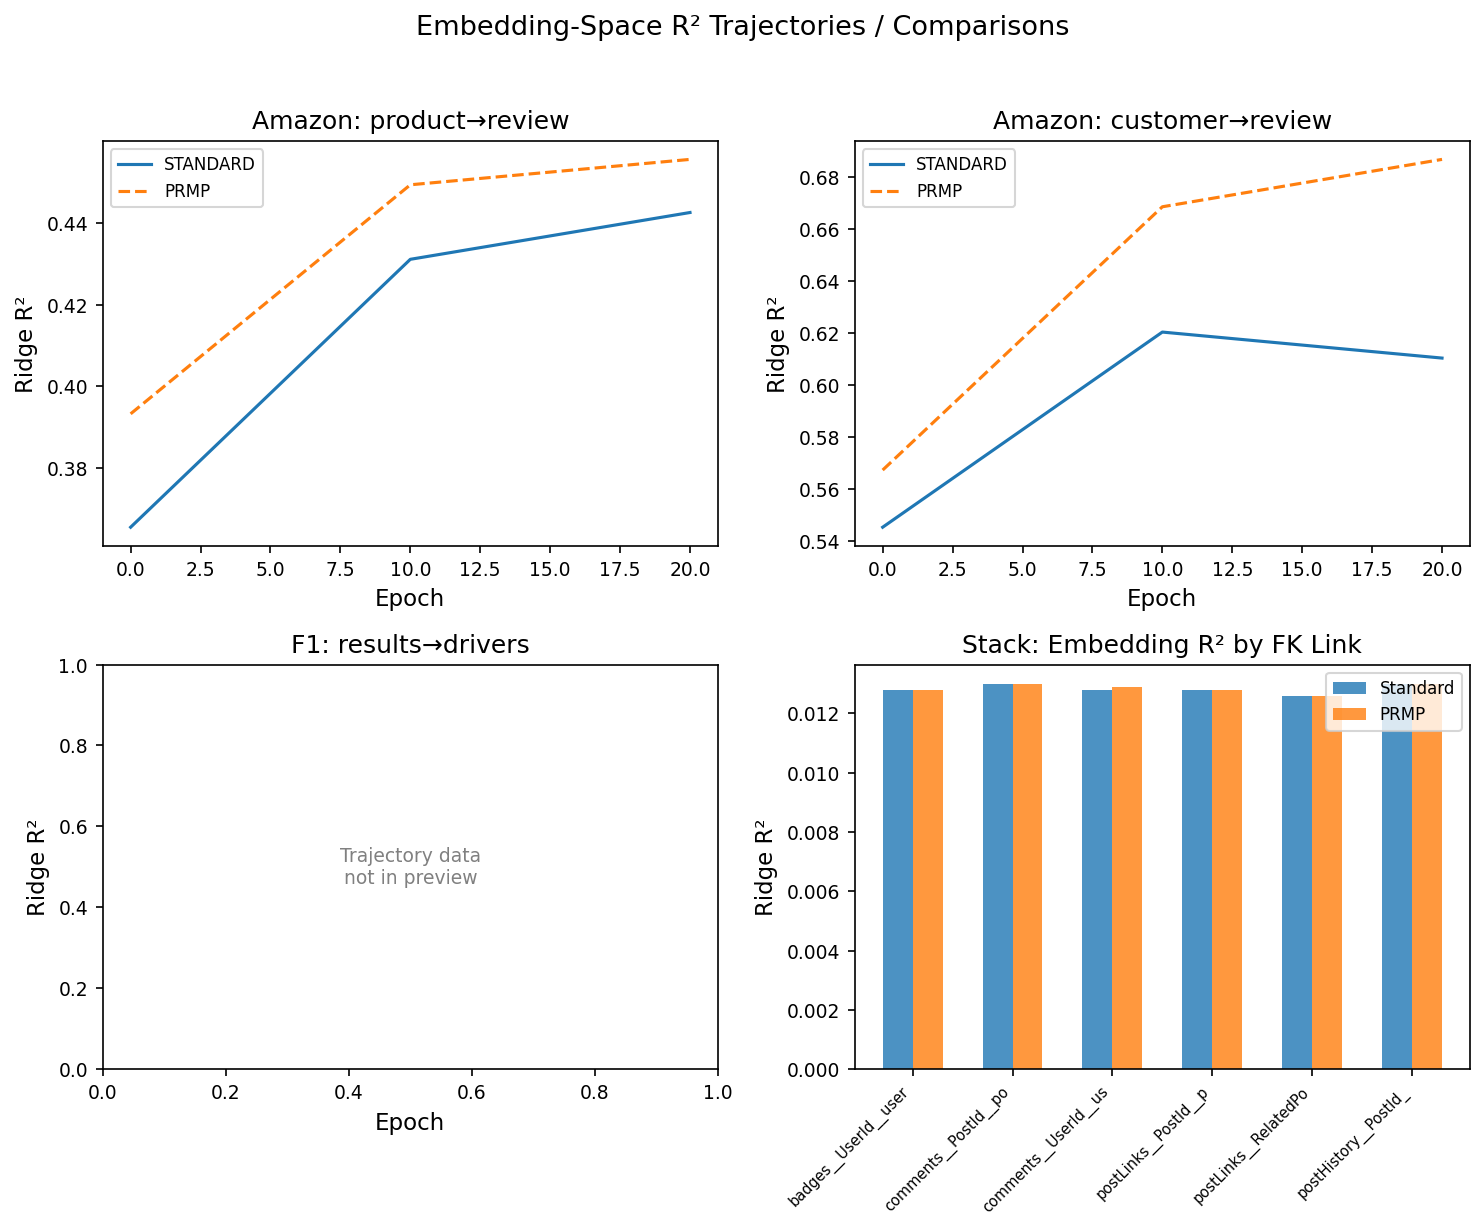

In [16]:
fig3, axes3 = plt.subplots(2, 2, figsize=(10, 8))
trajectories = data.get("embedding_trajectories", {})
stack_emb = data.get("stack_embedding_summary", {})

# Panel 1: Amazon product_to_review
ax = axes3[0, 0]
for model, style in [("standard", "-"), ("prmp", "--")]:
    if model in trajectories and "product_to_review" in trajectories[model]:
        d = trajectories[model]["product_to_review"]
        ax.plot(d["epochs"], d["ridge_r2"], style, label=model.upper(), linewidth=1.5)
ax.set_title("Amazon: product→review")
ax.set_xlabel("Epoch")
ax.set_ylabel("Ridge R²")
ax.legend(fontsize=8)

# Panel 2: Amazon customer_to_review
ax = axes3[0, 1]
for model, style in [("standard", "-"), ("prmp", "--")]:
    if model in trajectories and "customer_to_review" in trajectories[model]:
        d = trajectories[model]["customer_to_review"]
        ax.plot(d["epochs"], d["ridge_r2"], style, label=model.upper(), linewidth=1.5)
ax.set_title("Amazon: customer→review")
ax.set_xlabel("Epoch")
ax.set_ylabel("Ridge R²")
ax.legend(fontsize=8)

# Panel 3: F1 placeholder
ax = axes3[1, 0]
ax.set_title("F1: results→drivers")
ax.text(0.5, 0.5, "Trajectory data\nnot in preview", transform=ax.transAxes,
       ha="center", va="center", fontsize=9, color="gray")
ax.set_xlabel("Epoch")
ax.set_ylabel("Ridge R²")

# Panel 4: Stack embedding R² bar chart
ax = axes3[1, 1]
stack_links = [(k, v) for k, v in stack_emb.items() if v.get("Standard_mean")]
if stack_links:
    link_names = [l[0][:20] for l in stack_links[:6]]
    std_vals = [l[1]["Standard_mean"] for l in stack_links[:6]]
    prmp_vals = [l[1].get("PRMP_mean", 0) for l in stack_links[:6]]
    x = np.arange(len(link_names))
    ax.bar(x - 0.15, std_vals, 0.3, label="Standard", alpha=0.8)
    ax.bar(x + 0.15, prmp_vals, 0.3, label="PRMP", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(link_names, rotation=45, ha="right", fontsize=7)
    ax.set_title("Stack: Embedding R² by FK Link")
    ax.set_ylabel("Ridge R²")
    ax.legend(fontsize=8)

fig3.suptitle("Embedding-Space R² Trajectories / Comparisons", y=1.02, fontsize=13)
fig3.tight_layout()
plt.show()

### Figure 4: Mechanism Ablation Bar Chart

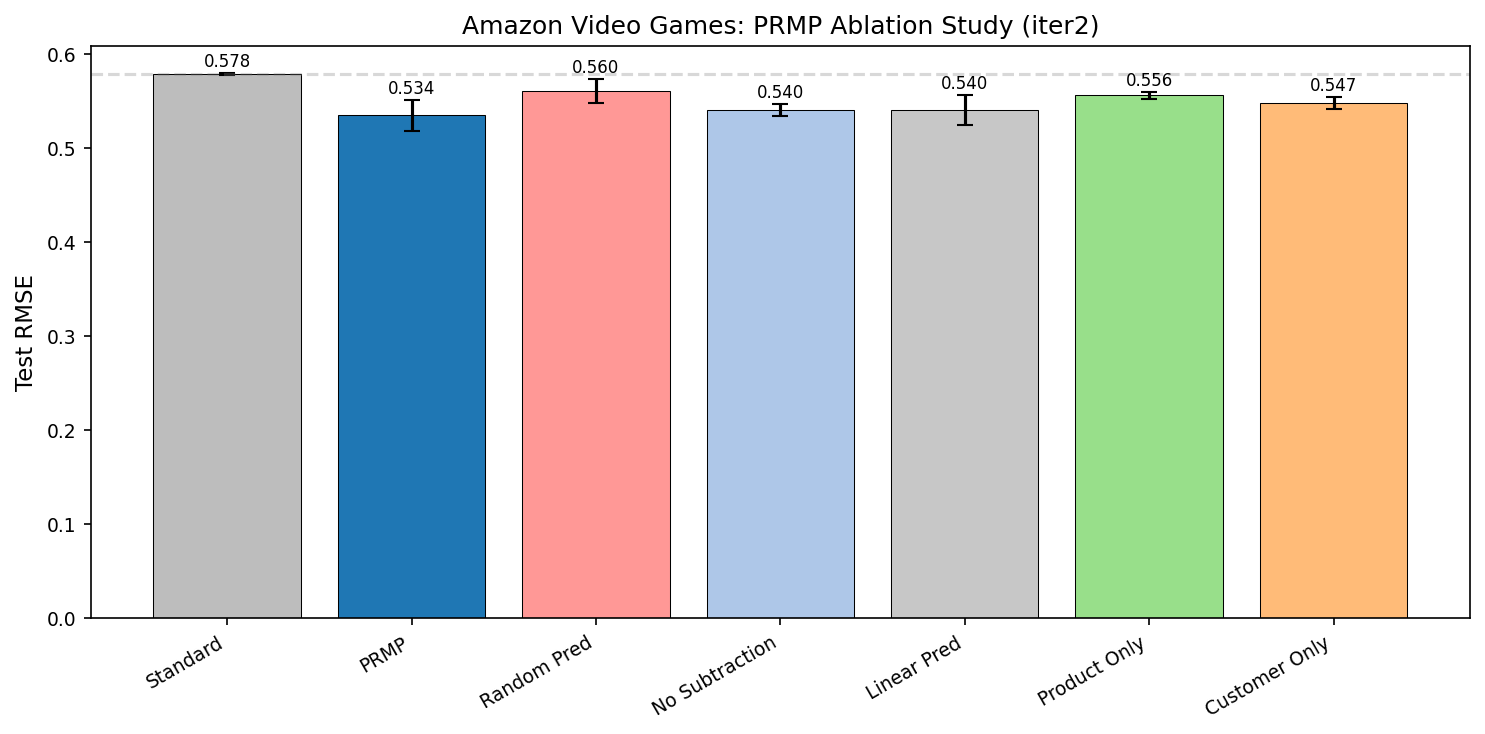

In [17]:
fig4, ax4 = plt.subplots(figsize=(10, 5))

ablation_fig_data = data["ablation_fig_data"]
variant_names = ["Standard", "PRMP", "Random Pred", "No Subtraction",
                 "Linear Pred", "Product Only", "Customer Only"]
rmse_means = [ablation_fig_data[k]["rmse_mean"] for k in variant_names]
rmse_stds = [ablation_fig_data[k]["rmse_std"] for k in variant_names]

colors4 = ["#bdbdbd", "#1f77b4", "#ff9896", "#aec7e8", "#c7c7c7", "#98df8a", "#ffbb78"]
x4 = np.arange(len(variant_names))
bars = ax4.bar(x4, rmse_means, yerr=rmse_stds, capsize=4, color=colors4, edgecolor="black", linewidth=0.5)
ax4.set_xticks(x4)
ax4.set_xticklabels(variant_names, rotation=30, ha="right")
ax4.set_ylabel("Test RMSE")
ax4.set_title("Amazon Video Games: PRMP Ablation Study (iter2)")
ax4.axhline(y=rmse_means[0], color="gray", linestyle="--", alpha=0.3)

for i, (m, s) in enumerate(zip(rmse_means, rmse_stds)):
    ax4.text(i, m + s + 0.003, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

fig4.tight_layout()
plt.show()

### Figure 5: Task-Type Subgroup Forest Plot

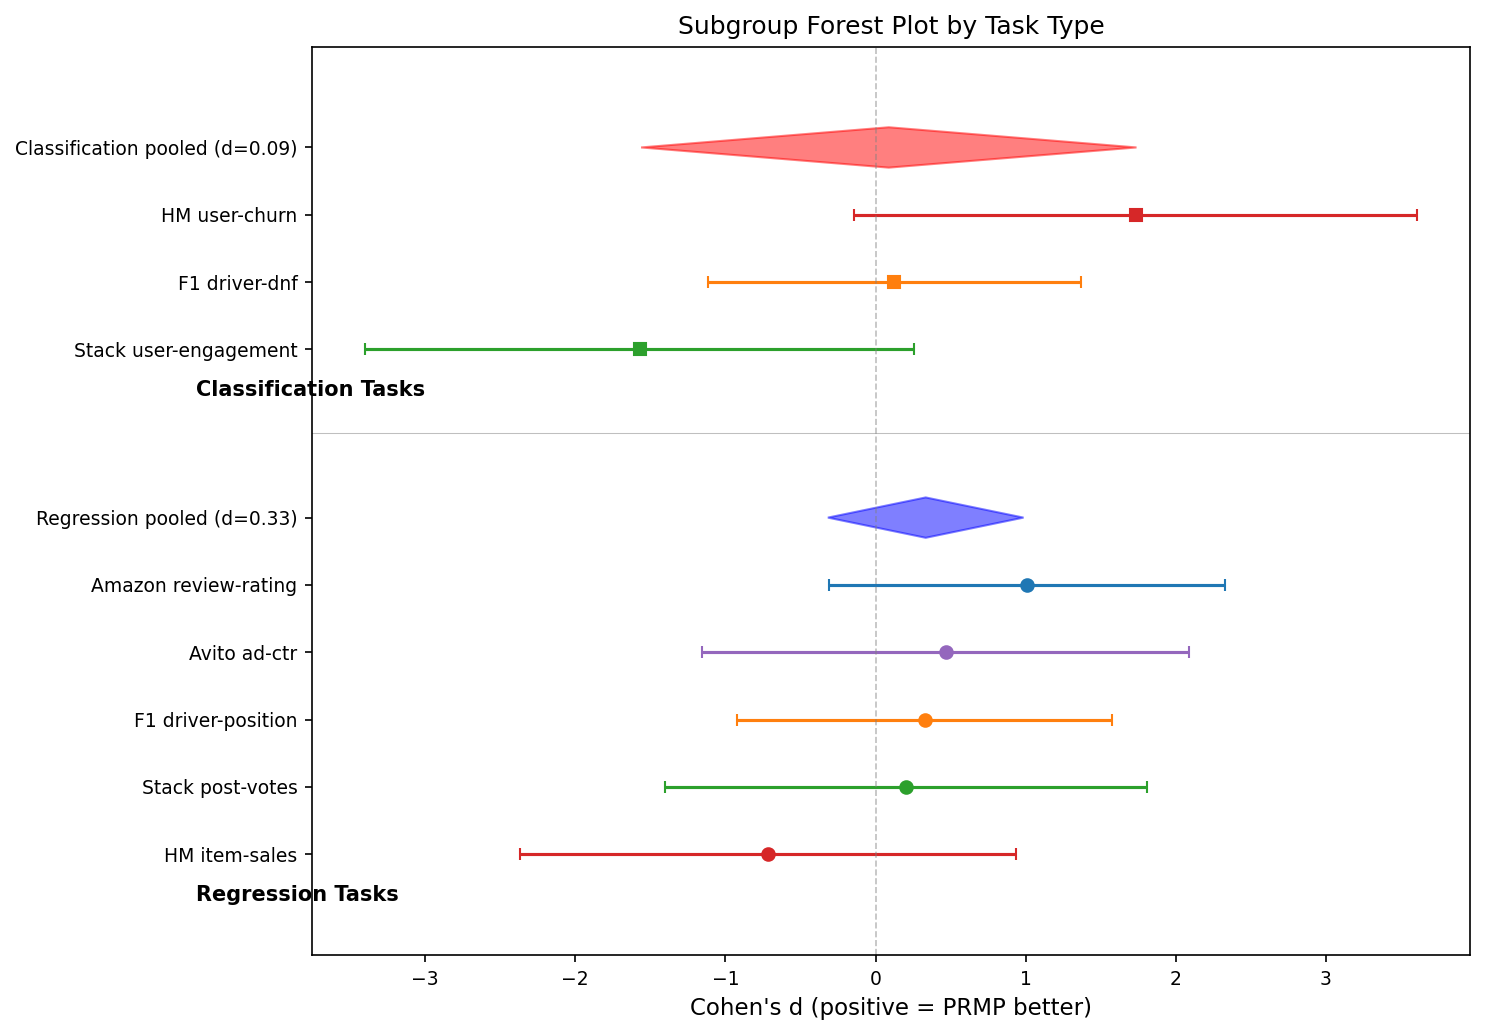

In [18]:
fig5, ax5 = plt.subplots(figsize=(10, 7))

y_pos = 0
y_labels = []
y_positions_5 = []

# Regression subgroup
ax5.text(-0.1, y_pos + 0.3, "Regression Tasks", fontweight="bold", fontsize=10,
        transform=ax5.get_yaxis_transform())
y_pos += 1
for t in sorted(reg_tasks, key=lambda x: x["d"]):
    color = dataset_colors.get(t["dataset"], "gray")
    ax5.errorbar(t["d"], y_pos, xerr=[[t["d"] - t["ci_lo"]], [t["ci_hi"] - t["d"]]],
                 fmt="o", color=color, markersize=6, capsize=3)
    y_labels.append(t["task"])
    y_positions_5.append(y_pos)
    y_pos += 1

if meta_reg:
    diamond_y_reg = y_pos
    diamond = plt.Polygon([
        [meta_reg["ci_lo"], diamond_y_reg],
        [meta_reg["pooled_d"], diamond_y_reg + 0.3],
        [meta_reg["ci_hi"], diamond_y_reg],
        [meta_reg["pooled_d"], diamond_y_reg - 0.3],
    ], closed=True, facecolor="blue", edgecolor="blue", alpha=0.5)
    ax5.add_patch(diamond)
    y_labels.append(f"Regression pooled (d={meta_reg['pooled_d']:.2f})")
    y_positions_5.append(diamond_y_reg)
    y_pos += 1

y_pos += 0.5
ax5.axhline(y=y_pos - 0.25, color="gray", linewidth=0.5, alpha=0.5)

# Classification subgroup
ax5.text(-0.1, y_pos + 0.3, "Classification Tasks", fontweight="bold", fontsize=10,
        transform=ax5.get_yaxis_transform())
y_pos += 1
for t in sorted(cls_tasks, key=lambda x: x["d"]):
    color = dataset_colors.get(t["dataset"], "gray")
    ax5.errorbar(t["d"], y_pos, xerr=[[t["d"] - t["ci_lo"]], [t["ci_hi"] - t["d"]]],
                 fmt="s", color=color, markersize=6, capsize=3)
    y_labels.append(t["task"])
    y_positions_5.append(y_pos)
    y_pos += 1

if meta_cls:
    diamond_y_cls = y_pos
    diamond = plt.Polygon([
        [meta_cls["ci_lo"], diamond_y_cls],
        [meta_cls["pooled_d"], diamond_y_cls + 0.3],
        [meta_cls["ci_hi"], diamond_y_cls],
        [meta_cls["pooled_d"], diamond_y_cls - 0.3],
    ], closed=True, facecolor="red", edgecolor="red", alpha=0.5)
    ax5.add_patch(diamond)
    y_labels.append(f"Classification pooled (d={meta_cls['pooled_d']:.2f})")
    y_positions_5.append(diamond_y_cls)
    y_pos += 1

ax5.axvline(x=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax5.set_yticks(y_positions_5)
ax5.set_yticklabels(y_labels, fontsize=9)
ax5.set_xlabel("Cohen's d (positive = PRMP better)")
ax5.set_title("Subgroup Forest Plot by Task Type")
ax5.set_ylim(-0.5, y_pos + 0.5)
fig5.tight_layout()
plt.show()

### Figure 6: Funnel Plot

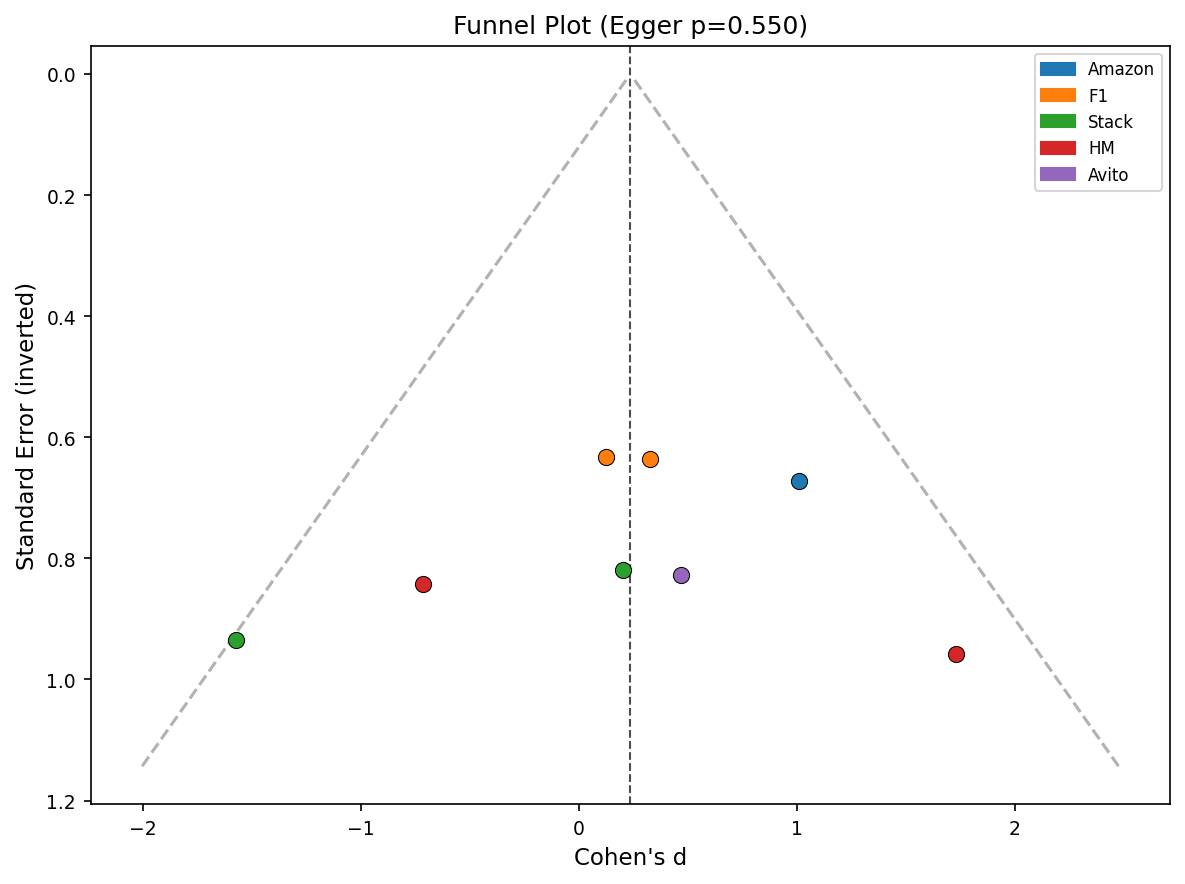

In [19]:
fig6, ax6 = plt.subplots(figsize=(8, 6))

for t in independent_tasks:
    color = dataset_colors.get(t["dataset"], "gray")
    ax6.scatter(t["d"], t["se"], color=color, s=60, edgecolors="black", linewidth=0.5, zorder=5)

ax6.axvline(x=meta_result["pooled_d"], color="black", linestyle="--", linewidth=1, alpha=0.7)

se_max = max(se_list) * 1.2
se_range = np.linspace(0.01, se_max, 100)
ax6.plot(meta_result["pooled_d"] - CONFIDENCE_LEVEL * se_range, se_range, "k--", alpha=0.3)
ax6.plot(meta_result["pooled_d"] + CONFIDENCE_LEVEL * se_range, se_range, "k--", alpha=0.3)

ax6.invert_yaxis()
ax6.set_xlabel("Cohen's d")
ax6.set_ylabel("Standard Error (inverted)")
ax6.set_title(f"Funnel Plot (Egger p={egger['p_value']:.3f})")

handles = [mpatches.Patch(color=c, label=ds) for ds, c in dataset_colors.items()
           if any(t["dataset"] == ds for t in independent_tasks)]
ax6.legend(handles=handles, loc="upper right", fontsize=8)
fig6.tight_layout()
plt.show()

### Figure 7: Loss-Swap Results

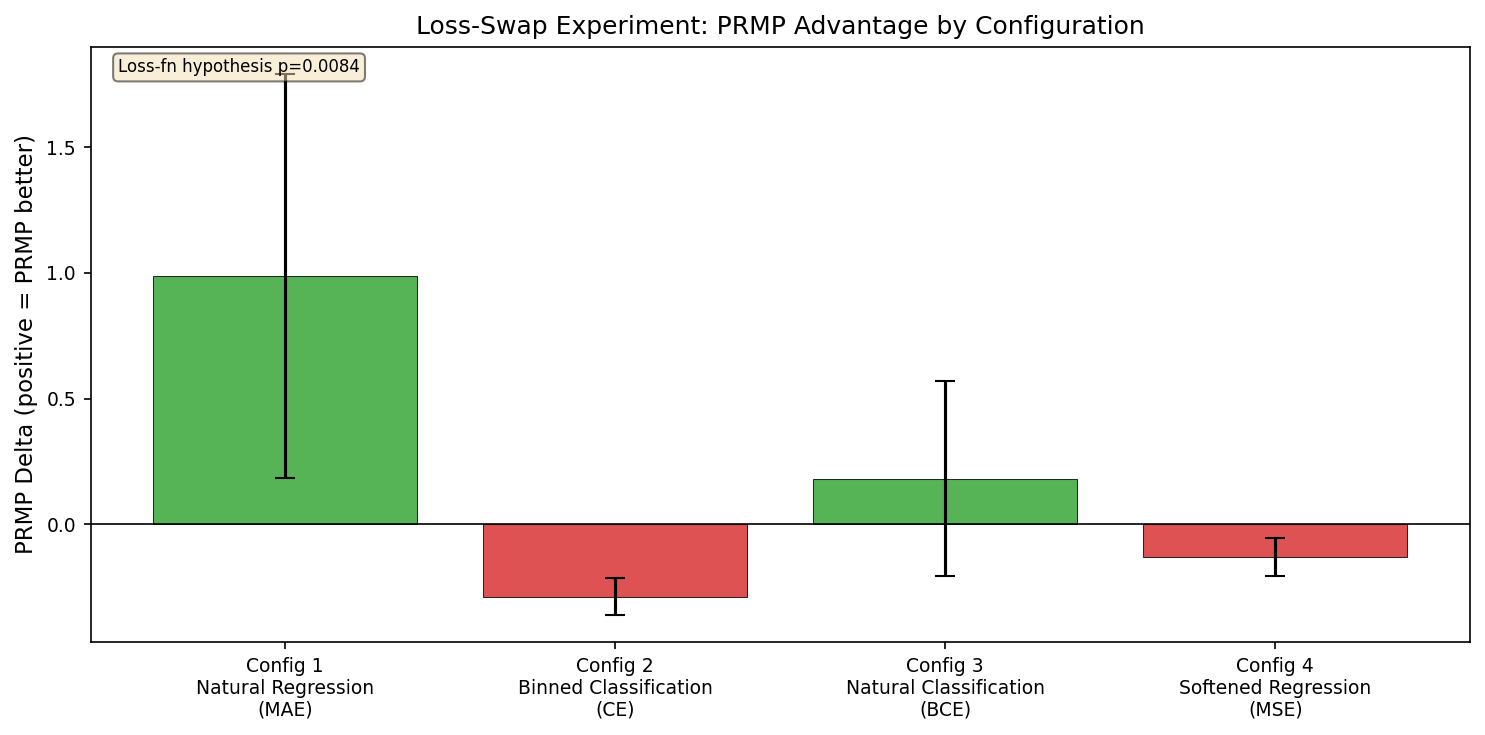

In [20]:
fig7, ax7 = plt.subplots(figsize=(10, 5))

lossswap_configs = data["lossswap_configs"]
lossswap_analysis = data["lossswap_analysis"]

config_names = [
    "Config 1\nNatural Regression\n(MAE)",
    "Config 2\nBinned Classification\n(CE)",
    "Config 3\nNatural Classification\n(BCE)",
    "Config 4\nSoftened Regression\n(MSE)",
]

delta_means = [c["delta_mean"] for c in lossswap_configs]
delta_stds = [c["delta_std"] for c in lossswap_configs]

x7 = np.arange(len(config_names))
bar_colors = ["#2ca02c" if dm > 0 else "#d62728" for dm in delta_means]
bars7 = ax7.bar(x7, delta_means, yerr=delta_stds, capsize=5, color=bar_colors,
               edgecolor="black", linewidth=0.5, alpha=0.8)
ax7.set_xticks(x7)
ax7.set_xticklabels(config_names, fontsize=9)
ax7.set_ylabel("PRMP Delta (positive = PRMP better)")
ax7.set_title("Loss-Swap Experiment: PRMP Advantage by Configuration")
ax7.axhline(y=0, color="black", linewidth=0.8)

lf_hyp = lossswap_analysis.get("loss_function_hypothesis", {})
p_val = lf_hyp.get("p_value", "N/A")
if isinstance(p_val, (int, float)):
    ax7.annotate(f"Loss-fn hypothesis p={p_val:.4f}",
                xy=(0.02, 0.98), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig7.tight_layout()
plt.show()

### Figure 8: Cross-Dataset Summary Table

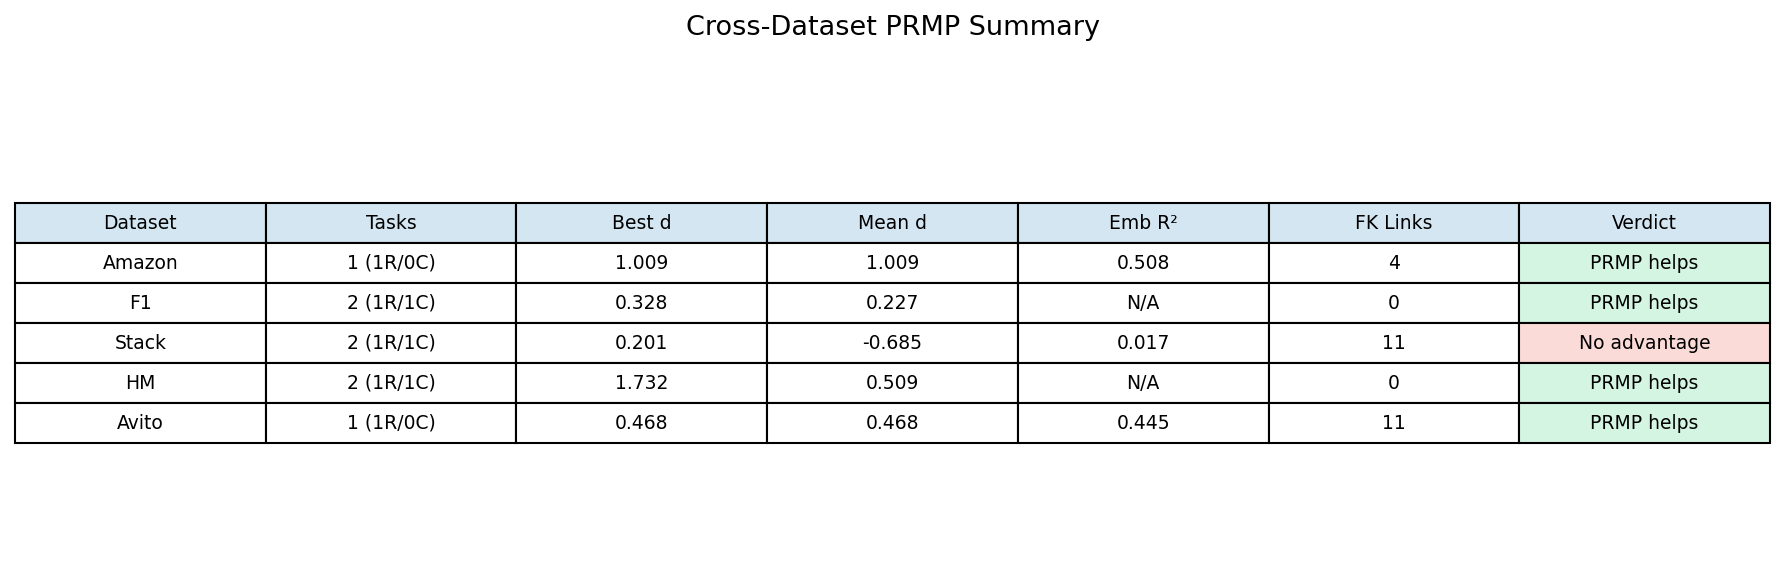

In [21]:
fig8, ax8 = plt.subplots(figsize=(12, 4))
ax8.axis("off")

col_labels = ["Dataset", "Tasks", "Best d", "Mean d", "Emb R²", "FK Links", "Verdict"]
table_data = []
for ds in ["Amazon", "F1", "Stack", "HM", "Avito"]:
    s = dataset_summary[ds]
    best_d = f"{s['best_d']:.3f}" if s['best_d'] is not None else "N/A"
    mean_d = f"{s['mean_d']:.3f}" if s['mean_d'] is not None else "N/A"
    emb_r2 = f"{s['mean_embedding_r2']:.3f}" if not np.isnan(s['mean_embedding_r2']) else "N/A"
    if s['mean_d'] is not None and s['mean_d'] > 0.2:
        verdict = "PRMP helps"
    elif s['mean_d'] is not None and s['mean_d'] > 0:
        verdict = "~ Marginal"
    elif s['mean_d'] is not None:
        verdict = "No advantage"
    else:
        verdict = "N/A"
    table_data.append([ds, f"{s['n_tasks']} ({s['n_regression']}R/{s['n_classification']}C)",
                      best_d, mean_d, emb_r2, str(s['n_fk_links']), verdict])

table = ax8.table(cellText=table_data, colLabels=col_labels, loc="center",
                 cellLoc="center", colColours=["#d4e6f1"] * len(col_labels))
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.5)

n_cols = len(col_labels)
for i, row in enumerate(table_data):
    if "helps" in row[-1]:
        table[i + 1, n_cols - 1].set_facecolor("#d5f5e3")
    elif "Marginal" in row[-1]:
        table[i + 1, n_cols - 1].set_facecolor("#fdebd0")
    elif "No" in row[-1]:
        table[i + 1, n_cols - 1].set_facecolor("#fadbd8")

ax8.set_title("Cross-Dataset PRMP Summary", fontsize=13, pad=20)
fig8.tight_layout()
plt.show()

## Results Summary

In [22]:
# Print final results table
print("=" * 80)
print("PRMP META-ANALYSIS RESULTS SUMMARY")
print("=" * 80)
print(f"\nPooled Cohen's d: {meta_result['pooled_d']:.4f} (95% CI: [{meta_result['ci_lo']:.4f}, {meta_result['ci_hi']:.4f}])")
print(f"Z-statistic: {meta_result['z']:.3f}, p-value: {meta_result['p_value']:.4f}")
print(f"Heterogeneity: I² = {meta_result['I2']:.1f}%, τ² = {meta_result['tau2']:.4f}")
print(f"Number of independent tasks: {meta_result['k']}")
print(f"\nSubgroup analysis:")
if meta_reg:
    print(f"  Regression (k={len(reg_tasks)}): d = {meta_reg['pooled_d']:.4f}")
if meta_cls:
    print(f"  Classification (k={len(cls_tasks)}): d = {meta_cls['pooled_d']:.4f}")
print(f"\nEmbedding regime theory:")
print(f"  Spearman ρ = {spearman_rho:.3f} (p = {spearman_p:.3f})")
print(f"\nEgger's test: intercept = {egger['intercept']:.3f} (p = {egger['p_value']:.3f})")
print(f"\nHypothesis verdicts:")
for k, v in verdicts.items():
    status = "SUPPORTED" if v["supported"] else "NOT SUPPORTED"
    print(f"  {k}: {status}")
    print(f"    {v['interpretation']}")
print("\n" + "=" * 80)
print("\nPer-task effect sizes:")
print(f"{'Task':<25} {'Dataset':<10} {'Type':<15} {'d':>8} {'SE':>8} {'95% CI':>20}")
print("-" * 90)
for t in sorted(independent_tasks, key=lambda x: -x["d"]):
    ci = f"[{t['ci_lo']:.3f}, {t['ci_hi']:.3f}]"
    print(f"{t['task']:<25} {t['dataset']:<10} {t['task_type']:<15} {t['d']:>8.3f} {t['se']:>8.3f} {ci:>20}")
print("-" * 90)

PRMP META-ANALYSIS RESULTS SUMMARY

Pooled Cohen's d: 0.2367 (95% CI: [-0.3651, 0.8384])
Z-statistic: 0.771, p-value: 0.4408
Heterogeneity: I² = 21.5%, τ² = 0.1611
Number of independent tasks: 8

Subgroup analysis:
  Regression (k=5): d = 0.3340
  Classification (k=3): d = 0.0881

Embedding regime theory:
  Spearman ρ = 0.949 (p = 0.051)

Egger's test: intercept = -1.411 (p = 0.550)

Hypothesis verdicts:
  H1_systematic_advantage: NOT SUPPORTED
    Pooled d=0.237 (p=0.4408), not significant
  H2_regime_theory: SUPPORTED
    ρ=0.949 (p=0.051), supported
  H3_regression_advantage: SUPPORTED
    Reg d=0.334 vs Cls d=0.088
  H4_learned_predictions_necessary: SUPPORTED
    PRMP RMSE=0.5343 vs Random RMSE=0.5601


Per-task effect sizes:
Task                      Dataset    Type                   d       SE               95% CI
------------------------------------------------------------------------------------------
HM user-churn             HM         classification     1.732    0.957      